In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 
import xbudget
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xbudget_dict = xbudget.load_yaml("ECCOV4r4.yaml").copy()

xarray: 2025.10.1
xgcm: 0.9.0


In [6]:
ecco_budget = xr.open_mfdataset("../data/data/ECCO_budget_terms.zarr")
ecco_budget = ecco_budget.chunk({"k_l":-1, "tile":-1, "i_g": -1, "j": -1, "j_g":-1, "i":-1})
ecco_budget = ecco_budget.fillna(0.0)
# ecco_budget = ecco_budget.chunk({"k_l":-1}).fillna(0.0)

grid = construct_grid(ecco_budget)

dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})
dt = dt.dt.total_seconds() #nice! 

xbudget.collect_budgets(grid, xbudget_dict)
# simple_budgets = xbudget.aggregate(xbudget_dict)
# simple_budgets

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:231: UserWarning: Variable mass_rhs_sum is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove mass_rhs_sum from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:231: UserWarning: Variable mass_rhs_sum_advection_sum is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove mass_rhs_sum_advection_sum from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library

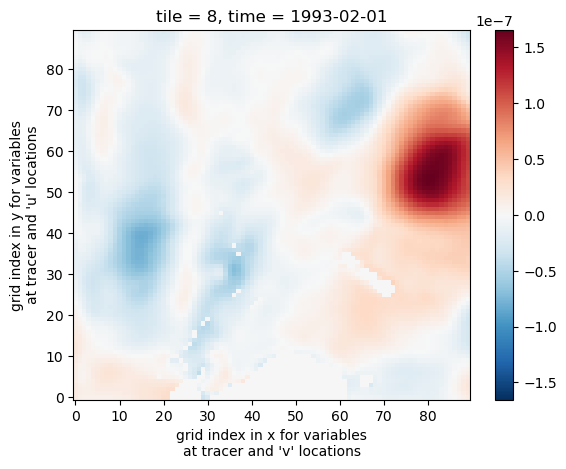

In [7]:
deta_dt = grid._ds["ETAN_bounds"].diff("time_bounds").rename({"time_bounds":"time"}) / dt
deta_dt.isel(time = 0, tile = 8).plot()


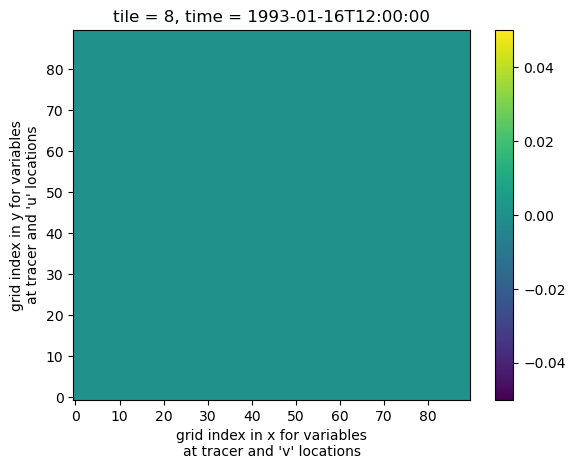

In [8]:
adv_conv = grid._ds[xbudget.get_vars(xbudget_dict, "mass_rhs_sum_advection_sum")['var']]
adv_conv = adv_conv / (adv_conv.rA  * 1035)
adv_conv.isel(time = 0, tile = 8).sum("k").plot()